# Analisi del dataset Palmer Penguins

1. Importazione e analisi esplorativa
2. Visualizzazioni esplorative
3. Preparazione dei dati (tipi, codifiche, classi)
4. Pulizia dei dati (missing value)
5. Analisi statistica (covarianza, correlazione, indipendenza, eta quadro)
6. Regressione lineare
7. Conclusioni


In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.api as sm

sns.set_theme()
pd.set_option('display.max_columns', None)


## Immagini di riferimento

La prima immagine proviene dalla documentazione di Google Developers e distingue le tre specie di pinguini prese in esame. La seconda immagine proviene dal pacchetto *palmerpenguins* di Allison Horst e mostra le misure del becco (*culmen*)

![Tre specie di pinguini](https://developers.google.com/static/machine-learning/decision-forests/images/ThreePenguinSpecies.png)

![Misure del becco (culmen)](https://allisonhorst.github.io/palmerpenguins/reference/figures/culmen_depth.png)


# 1. Importazione e analisi esplorativa

In [2]:
# Importazione del dataset
df = pd.read_csv('penguins.csv')
df.shape

(344, 8)

In [3]:
# Traduzione dei nomi delle colonne in italiano
df.columns = ['specie', 'isola', 'lunghezza_becco_mm', 'altezza_becco_mm',
              'lunghezza_pinna_mm', 'massa_corporea_g', 'sesso', 'anno']
df.columns

Index(['specie', 'isola', 'lunghezza_becco_mm', 'altezza_becco_mm',
       'lunghezza_pinna_mm', 'massa_corporea_g', 'sesso', 'anno'],
      dtype='str')

In [4]:
# Traduzione dei nomi della colonna sesso
df['sesso'] = df['sesso'].replace({'male': 'maschio', 'female': 'femmina'})
df['sesso'].unique()

<StringArray>
['maschio', 'femmina', nan]
Length: 3, dtype: str

In [5]:
df.sample(5, random_state=1)

,specie,isola,lunghezza_becco_mm,altezza_becco_mm,lunghezza_pinna_mm,massa_corporea_g,sesso,anno
306,Chinstrap,Dream,40.9,16.6,187.0,3200.0,femmina,2008
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,maschio,2009
291,Chinstrap,Dream,50.5,19.6,201.0,4050.0,maschio,2007
102,Adelie,Biscoe,37.7,16.0,183.0,3075.0,femmina,2009
289,Chinstrap,Dream,52.0,18.1,201.0,4050.0,maschio,2007


In [6]:
df.info()  # tipi di dato, numero di righe/colonne, valori non nulli

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   specie              344 non-null    str    
 1   isola               344 non-null    str    
 2   lunghezza_becco_mm  342 non-null    float64
 3   altezza_becco_mm    342 non-null    float64
 4   lunghezza_pinna_mm  342 non-null    float64
 5   massa_corporea_g    342 non-null    float64
 6   sesso               333 non-null    str    
 7   anno                344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [7]:
df.describe().round(2)  # statistiche di sintesi delle variabili numeriche

,lunghezza_becco_mm,altezza_becco_mm,lunghezza_pinna_mm,massa_corporea_g,anno
count,342.00,342.00,342.00,342.00,344.00
mean,43.92,17.15,200.92,4201.75,2008.03
std,5.46,1.97,14.06,801.95,0.82
min,32.10,13.10,172.00,2700.00,2007.00
25%,39.22,15.60,190.00,3550.00,2007.00
50%,44.45,17.30,197.00,4050.00,2008.00
75%,48.50,18.70,213.00,4750.00,2009.00
max,59.60,21.50,231.00,6300.00,2009.00


In [8]:
df.nunique()  # modalità distinte per ogni colonna

specie                  3
isola                   3
lunghezza_becco_mm    164
altezza_becco_mm       80
lunghezza_pinna_mm     55
massa_corporea_g       94
sesso                   2
anno                    3
dtype: int64

In [9]:
(df.nunique() / len(df)).round(3)  # modalità distinte / numero osservazioni = rapporto di cardinalità

specie                0.009
isola                 0.009
lunghezza_becco_mm    0.477
altezza_becco_mm      0.233
lunghezza_pinna_mm    0.160
massa_corporea_g      0.273
sesso                 0.006
anno                  0.009
dtype: float64

In [10]:
# Modalità distinte delle variabili categoriche
df.specie.unique(), df.isola.unique(), df.sesso.unique(), df.anno.unique()

(<StringArray>
 ['Adelie', 'Gentoo', 'Chinstrap']
 Length: 3, dtype: str,
 <StringArray>
 ['Torgersen', 'Biscoe', 'Dream']
 Length: 3, dtype: str,
 <StringArray>
 ['maschio', 'femmina', nan]
 Length: 3, dtype: str,
 array([2007, 2008, 2009]))

### Valori mancanti

In [11]:
df.isna().sum(axis=0)  # missing value per colonna

specie                 0
isola                  0
lunghezza_becco_mm     2
altezza_becco_mm       2
lunghezza_pinna_mm     2
massa_corporea_g       2
sesso                 11
anno                   0
dtype: int64

In [12]:
df.isna().mean(axis=0).round(3)  # quota di missing value per colonna

specie                0.000
isola                 0.000
lunghezza_becco_mm    0.006
altezza_becco_mm      0.006
lunghezza_pinna_mm    0.006
massa_corporea_g      0.006
sesso                 0.032
anno                  0.000
dtype: float64

In [13]:
df[df.isna().any(axis=1)]  # tutte le righe con almeno un valore mancante

,specie,isola,lunghezza_becco_mm,altezza_becco_mm,lunghezza_pinna_mm,massa_corporea_g,sesso,anno
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


In [14]:
df[df.isna().sum(axis=1) > 1]  # righe con più di un valore mancante

,specie,isola,lunghezza_becco_mm,altezza_becco_mm,lunghezza_pinna_mm,massa_corporea_g,sesso,anno
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


# 2. Visualizzazioni esplorative

### Distribuzione della massa corporea per sesso, specie e isola

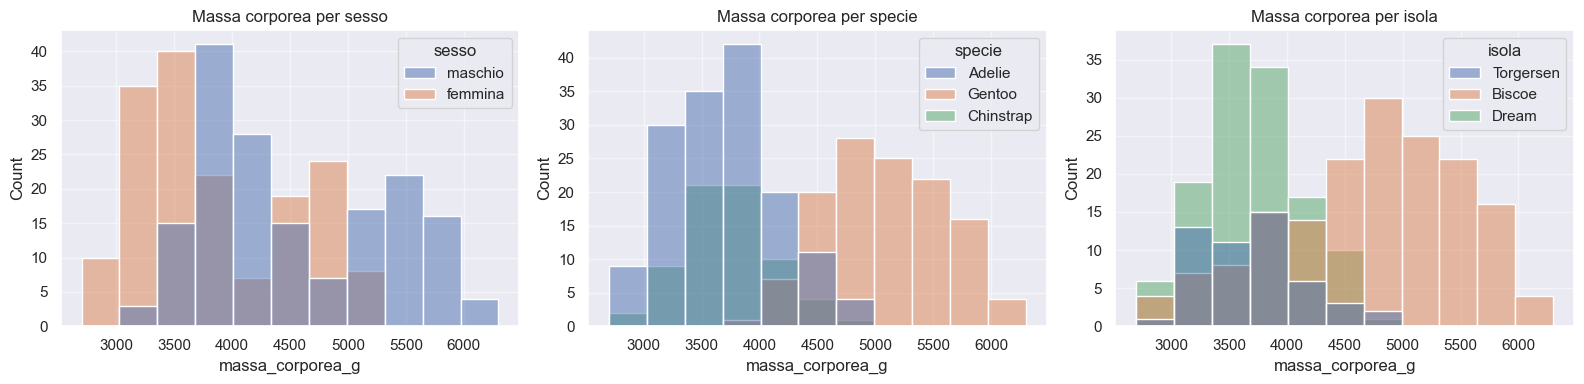

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=df, x='massa_corporea_g', hue='sesso', ax=axes[0])
axes[0].set_title('Massa corporea per sesso')
sns.histplot(data=df, x='massa_corporea_g', hue='specie', ax=axes[1])
axes[1].set_title('Massa corporea per specie')
sns.histplot(data=df, x='massa_corporea_g', hue='isola', ax=axes[2])
axes[2].set_title('Massa corporea per isola')
plt.tight_layout()
plt.show()

In [16]:
# Stessa informazione dell'istogramma, in forma testuale (classi di massa per sesso)
for sesso, gruppo in df.groupby('sesso')['massa_corporea_g']:
    print(f"\nSesso: {sesso}")
    print(pd.cut(gruppo, bins=10).value_counts().sort_index().to_string())


Sesso: femmina
massa_corporea_g
(2697.5, 2950.0]     8
(2950.0, 3200.0]    19
(3200.0, 3450.0]    33
(3450.0, 3700.0]    33
(3700.0, 3950.0]    14
(3950.0, 4200.0]     5
(4200.0, 4450.0]    10
(4450.0, 4700.0]    16
(4700.0, 4950.0]    18
(4950.0, 5200.0]     9

Sesso: maschio
massa_corporea_g
(3246.95, 3555.0]    13
(3555.0, 3860.0]     23
(3860.0, 4165.0]     38
(4165.0, 4470.0]     21
(4470.0, 4775.0]     12
(4775.0, 5080.0]      7
(5080.0, 5385.0]     15
(5385.0, 5690.0]     22
(5690.0, 5995.0]     13
(5995.0, 6300.0]      4


In [17]:
# Stessa informazione dell'istogramma, in forma testuale (classi di massa per specie)
for specie, gruppo in df.groupby('specie')['massa_corporea_g']:
    print(f"\nSpecie: {specie}")
    print(pd.cut(gruppo, bins=10).value_counts().sort_index().to_string())


Specie: Adelie
massa_corporea_g
(2848.075, 3042.5]     9
(3042.5, 3235.0]      16
(3235.0, 3427.5]      20
(3427.5, 3620.0]      26
(3620.0, 3812.5]      25
(3812.5, 4005.0]      20
(4005.0, 4197.5]       8
(4197.5, 4390.0]      13
(4390.0, 4582.5]       7
(4582.5, 4775.0]       7

Specie: Chinstrap
massa_corporea_g
(2697.9, 2910.0]     2
(2910.0, 3120.0]     0
(3120.0, 3330.0]     7
(3330.0, 3540.0]    12
(3540.0, 3750.0]    17
(3750.0, 3960.0]    14
(3960.0, 4170.0]     9
(4170.0, 4380.0]     2
(4380.0, 4590.0]     4
(4590.0, 4800.0]     1

Specie: Gentoo
massa_corporea_g
(3947.65, 4185.0]     3
(4185.0, 4420.0]     11
(4420.0, 4655.0]     14
(4655.0, 4890.0]     21
(4890.0, 5125.0]     19
(5125.0, 5360.0]     16
(5360.0, 5595.0]     17
(5595.0, 5830.0]     13
(5830.0, 6065.0]      8
(6065.0, 6300.0]      1


In [18]:
# Stessa informazione dell'istogramma, in forma testuale (classi di massa per isola)
for isola, gruppo in df.groupby('isola')['massa_corporea_g']:
    print(f"\nIsola: {isola}")
    print(pd.cut(gruppo, bins=10).value_counts().sort_index().to_string())


Isola: Biscoe
massa_corporea_g
(2846.55, 3195.0]     8
(3195.0, 3540.0]      6
(3540.0, 3885.0]     14
(3885.0, 4230.0]     15
(4230.0, 4575.0]     17
(4575.0, 4920.0]     35
(4920.0, 5265.0]     26
(5265.0, 5610.0]     26
(5610.0, 5955.0]     16
(5955.0, 6300.0]      4

Isola: Dream
massa_corporea_g
(2697.9, 2910.0]     3
(2910.0, 3120.0]     5
(3120.0, 3330.0]    14
(3330.0, 3540.0]    24
(3540.0, 3750.0]    26
(3750.0, 3960.0]    21
(3960.0, 4170.0]    14
(4170.0, 4380.0]     7
(4380.0, 4590.0]     7
(4590.0, 4800.0]     3

Isola: Torgersen
massa_corporea_g
(2898.2, 3080.0]     4
(3080.0, 3260.0]     4
(3260.0, 3440.0]     6
(3440.0, 3620.0]     9
(3620.0, 3800.0]    11
(3800.0, 3980.0]     3
(3980.0, 4160.0]     4
(4160.0, 4340.0]     5
(4340.0, 4520.0]     3
(4520.0, 4700.0]     2


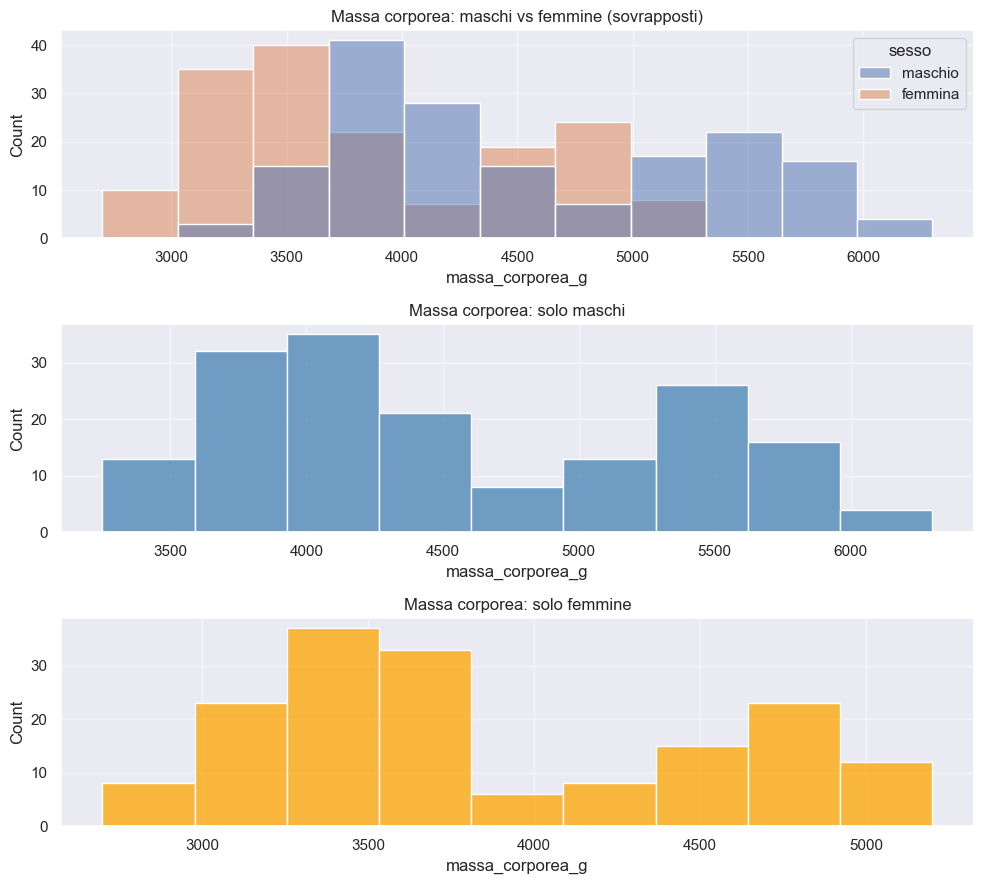

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(10, 9))
sns.histplot(data=df, x='massa_corporea_g', hue='sesso', ax=ax1)
ax1.set_title('Massa corporea: maschi vs femmine (sovrapposti)')
sns.histplot(data=df[df['sesso'] == 'maschio'], x='massa_corporea_g', ax=ax2, color='steelblue')
ax2.set_title('Massa corporea: solo maschi')
sns.histplot(data=df[df['sesso'] == 'femmina'], x='massa_corporea_g', ax=ax3, color='orange')
ax3.set_title('Massa corporea: solo femmine')
plt.tight_layout()
plt.show()

### Relazione massa corporea / lunghezza pinna

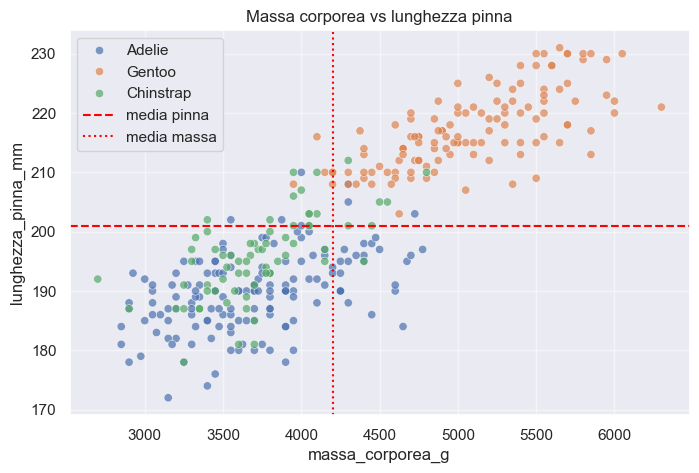

In [20]:
media_massa = df['massa_corporea_g'].mean()
media_pinna = df['lunghezza_pinna_mm'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='massa_corporea_g', y='lunghezza_pinna_mm', hue='specie', alpha=0.7, ax=ax)
ax.axhline(media_pinna, color='red', linestyle='--', label='media pinna')
ax.axvline(media_massa, color='red', linestyle=':', label='media massa')
ax.legend()
ax.set_title('Massa corporea vs lunghezza pinna')
plt.show()

I pinguini con massa corporea maggiore tendono ad avere anche le pinne più lunghe (correlazione positiva). Distinguendo i punti per specie (colore), si nota che le tre nuvole occupano zone diverse del grafico rappresentato dall'incrocio tra le medie della pinna e della massa: i Gentoo si concentrano nel quadrante in alto a destra (massa e pinna sopra la media), mentre Adelie e Chinstrap si sovrappongono maggiormente nella parte inferiore sinistra, pur mantenendo la stessa relazione positiva al loro interno.

In [21]:
df[['massa_corporea_g', 'lunghezza_pinna_mm']].cov()

,massa_corporea_g,lunghezza_pinna_mm
massa_corporea_g,643131.077327,9824.416062
lunghezza_pinna_mm,9824.416062,197.731792


In [22]:
df[['massa_corporea_g', 'lunghezza_pinna_mm']].corr()
# corr = cov(x,y) / sqrt(var(x) * var(y)) -> correlazione lineare positiva forte

,massa_corporea_g,lunghezza_pinna_mm
massa_corporea_g,1.000000,0.871202
lunghezza_pinna_mm,0.871202,1.000000


La correlazione tra massa corporea e lunghezza pinna (covarianza diviso le deviazioni standard delle due variabili) è **lineare forte**: all'aumentare della massa corporea, la lunghezza della pinna aumenta in modo quasi proporzionale. Infatti, i punti del grafico si distribuiscono molto vicini a una retta crescente.

### Relazione lunghezza / altezza del becco

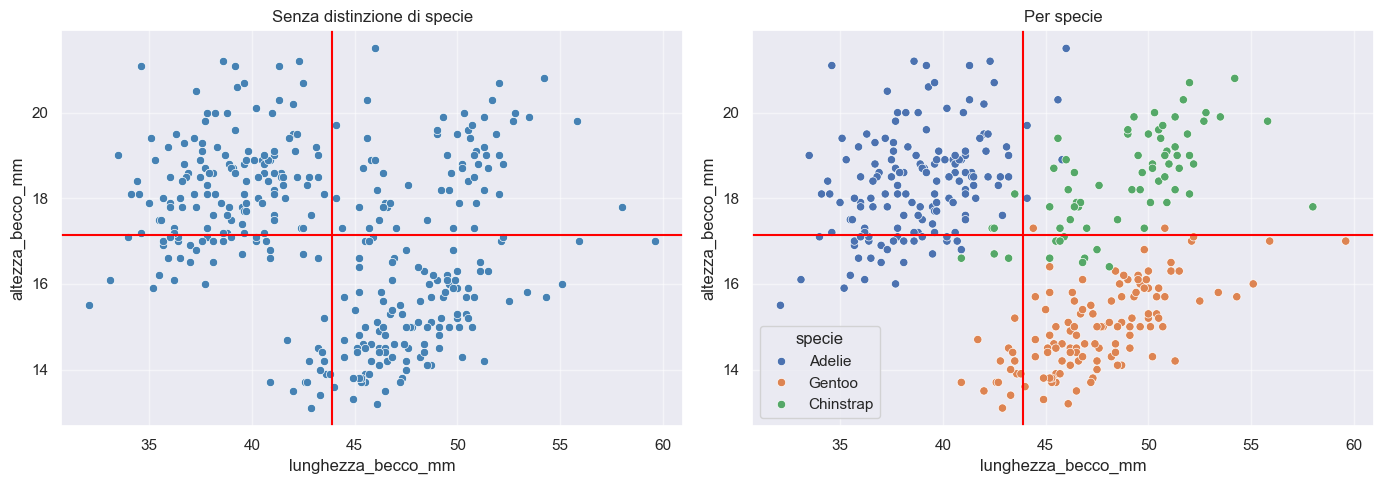

In [23]:
media_lb = df['lunghezza_becco_mm'].mean()
media_ab = df['altezza_becco_mm'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='lunghezza_becco_mm', y='altezza_becco_mm', ax=ax1, color='steelblue')
ax1.axhline(media_ab, color='red'); ax1.axvline(media_lb, color='red')
ax1.set_title('Senza distinzione di specie')

sns.scatterplot(data=df, x='lunghezza_becco_mm', y='altezza_becco_mm', hue='specie', ax=ax2)
ax2.axhline(media_ab, color='red'); ax2.axvline(media_lb, color='red')
ax2.set_title('Per specie')
plt.tight_layout()
plt.show()

Vi è un effetto di **variabile confondente**: guardando l'intero campione la relazione tra lunghezza e altezza del becco appare debole/negativa, ma se si distingue per specie emergono tre nuvole di punti ben separate, ciascuna con una relazione positiva al proprio interno (paradosso di Simpson).

In [24]:
df[['lunghezza_becco_mm', 'altezza_becco_mm']].cov()

,lunghezza_becco_mm,altezza_becco_mm
lunghezza_becco_mm,29.807054,-2.534234
altezza_becco_mm,-2.534234,3.899808


In [25]:
df[['lunghezza_becco_mm', 'altezza_becco_mm']].corr()

,lunghezza_becco_mm,altezza_becco_mm
lunghezza_becco_mm,1.000000,-0.235053
altezza_becco_mm,-0.235053,1.000000


In [26]:
# Correlazione per ciascuna specie
df.groupby('specie')[['lunghezza_becco_mm', 'altezza_becco_mm']].corr().iloc[0::2, 1]

specie                       
Adelie     lunghezza_becco_mm    0.391492
Chinstrap  lunghezza_becco_mm    0.653536
Gentoo     lunghezza_becco_mm    0.643384
Name: altezza_becco_mm, dtype: float64

Dentro ciascuna specie la relazione tra lunghezza e altezza del becco è sempre positiva, ma con intensità diversa, più moderata negli Adelie e più marcata nelle altre due specie

### Specie e isola: distribuzione congiunta

In [27]:
tabella_specie_isola = pd.crosstab(df['specie'], df['isola'], margins=True)
tabella_specie_isola

isola,Biscoe,Dream,Torgersen,All
specie,,,,
Adelie,44,56,52,152
Chinstrap,0,68,0,68
Gentoo,124,0,0,124
All,168,124,52,344


In [28]:
pd.crosstab(df['specie'], df['isola'], normalize='index').round(2)  # frequenze relative per riga

isola,Biscoe,Dream,Torgersen
specie,,,
Adelie,0.29,0.37,0.34
Chinstrap,0.00,1.00,0.00
Gentoo,1.00,0.00,0.00


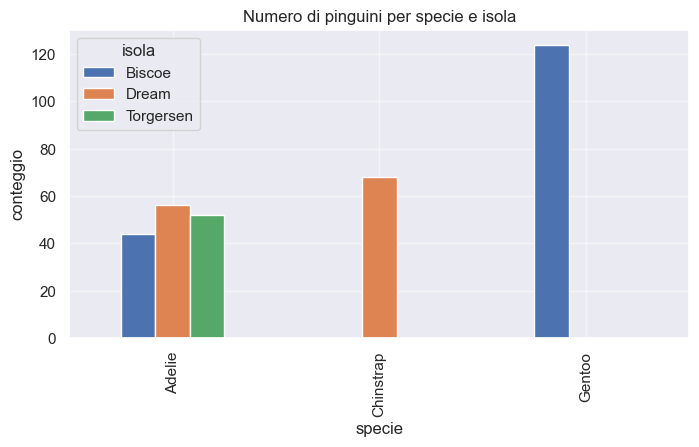

In [31]:
pd.crosstab(df['specie'], df['isola']).plot(kind='bar', figsize=(8, 4))
plt.title('Numero di pinguini per specie e isola')
plt.ylabel('conteggio')
plt.show()

Gli esemplari della specie Adelie si trovano su tutte e tre le isole, in proporzioni simili (29% Biscoe, 37% Dream, 34% Torgersen). I Chinstrap si trovano solo sull'isola Dream, e i Gentoo si trovano tutti sull'isola Biscoe.

### Test di indipendenza statistica (Chi-quadro e V di Cramer)

In [32]:
tabella = pd.crosstab(df['specie'], df['isola'])
chi2, p, dof, exp_freq = chi2_contingency(tabella)

r, s = tabella.shape
n = tabella.sum().sum()
cramer_v = np.sqrt(chi2 / (n * min(r - 1, s - 1)))

print(f"Chi-quadro = {chi2:.2f}")
print(f"p-value    = {p:.2e}")
print(f"df         = {dof}")
print(f"V di Cramer = {cramer_v:.2f}")

Chi-quadro = 299.55
p-value    = 1.35e-63
df         = 4
V di Cramer = 0.66


Il p-value è estremamente basso: si rifiuta l'ipotesi di indipendenza tra **specie** e **isola**. Il V di Cramer indica inoltre un'associazione molto forte: la specie osservata dipende fortemente dall'isola (ad esempio, Gentoo si trova solo a Biscoe, Chinstrap solo a Dream).

# 3. Preparazione dei dati

### Tipi di dato

In [33]:
# 'isola' è una variabile categorica nominale (non esiste un ordine naturale)
df['isola'] = df['isola'].astype('category')

# 'specie' è trattata come categorica ordinale (ordine alfabetico/di comparsa nel dataset)
cat_specie = pd.CategoricalDtype(['Adelie', 'Chinstrap', 'Gentoo'], ordered=True)
df['specie'] = df['specie'].astype(cat_specie)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   specie              344 non-null    category
 1   isola               344 non-null    category
 2   lunghezza_becco_mm  342 non-null    float64 
 3   altezza_becco_mm    342 non-null    float64 
 4   lunghezza_pinna_mm  342 non-null    float64 
 5   massa_corporea_g    342 non-null    float64 
 6   sesso               333 non-null    str     
 7   anno                344 non-null    int64   
dtypes: category(2), float64(4), int64(1), str(1)
memory usage: 17.1 KB


### Codifica della variabile sesso

In [34]:
# Codifica binaria: 1 = maschio, 0 = femmina (semplifica calcoli statistici successivi)
df['sesso'] = df['sesso'].replace({'maschio': 1, 'femmina': 0})
df['sesso'].unique()

array([1, 0, nan], dtype=object)

### Discretizzazione in classi (regola di Sturges)

In [36]:
# Regola di Sturges: numero di classi = 1 + log2(n), arrotondato per eccesso
k_sturges = 1 + np.log2(len(df))
n_bins = int(np.ceil(k_sturges))
print(f"k = 1 + log2({len(df)}) = {k_sturges:.2f} -> n_bins = {n_bins}")

for col in ['massa_corporea_g', 'lunghezza_becco_mm', 'altezza_becco_mm', 'lunghezza_pinna_mm']:
    df[col + '_class'] = pd.cut(df[col], bins=n_bins)

df[['massa_corporea_g', 'massa_corporea_g_class',
    'lunghezza_pinna_mm', 'lunghezza_pinna_mm_class']].head()

k = 1 + log2(344) = 9.43 -> n_bins = 10


,massa_corporea_g,massa_corporea_g_class,lunghezza_pinna_mm,lunghezza_pinna_mm_class
0,3750.0,"(3420.0, 3780.0]",181.0,"(177.9, 183.8]"
1,3800.0,"(3780.0, 4140.0]",186.0,"(183.8, 189.7]"
2,3250.0,"(3060.0, 3420.0]",195.0,"(189.7, 195.6]"
3,NaN,NaN,NaN,NaN
4,3450.0,"(3420.0, 3780.0]",193.0,"(189.7, 195.6]"


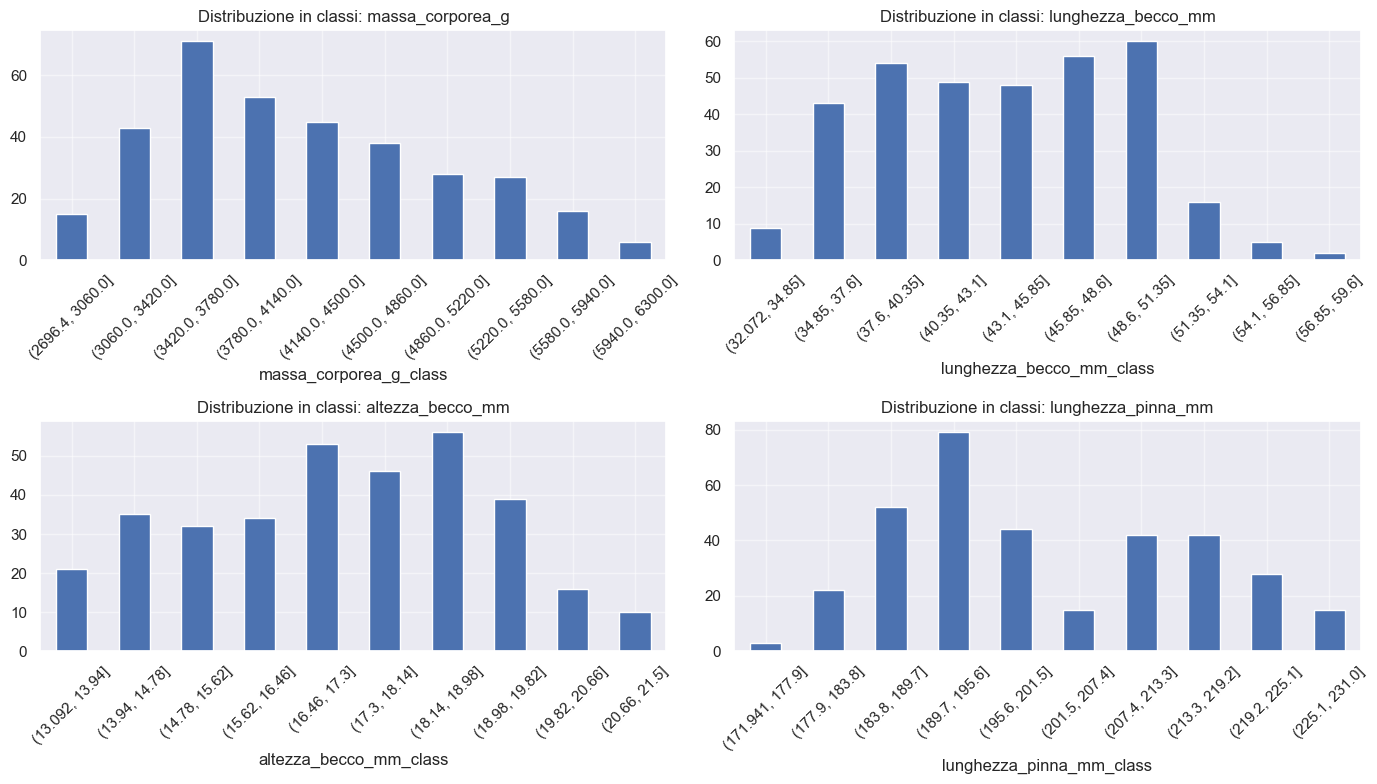

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
variabili = ['massa_corporea_g', 'lunghezza_becco_mm', 'altezza_becco_mm', 'lunghezza_pinna_mm']
for ax, var in zip(axes.flat, variabili):
    df[var + '_class'].value_counts().sort_index().plot(kind='bar', grid=True, ax=ax)
    ax.set_title(f'Distribuzione in classi: {var}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Guardando le quattro distribuzioni, emerge un pattern comune: **nessuna delle variabili è distribuita in modo perfettamente simmetrico né uniforme tra le classi**.
* La massa corporea ha il picco nella terza classe (3420-3780g, 71 osservazioni) con una coda più lunga verso i pesi alti, tipica di una distribuzione leggermente asimmetrica a destra;
* lunghezza e altezza del becco mostrano due o tre classi centrali dominanti circondate da code che si assottigliano gradualmente;
* la lunghezza della pinna ha un andamento più irregolare, con un doppio picco (intorno ai 190mm e di nuovo intorno ai 210-220mm), probabile riflesso del fatto che la specie Gentoo ha pinne sistematicamente più lunghe delle altre due specie e quindi "sposta" parte della distribuzione verso destra.

# 4. Pulizia dei dati (missing values)

In [38]:
df[df.isna().sum(axis=1) > 3]  # righe quasi completamente vuote

,specie,isola,lunghezza_becco_mm,altezza_becco_mm,lunghezza_pinna_mm,massa_corporea_g,sesso,anno,massa_corporea_g_class,lunghezza_becco_mm_class,altezza_becco_mm_class,lunghezza_pinna_mm_class
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,NaN,NaN,NaN,NaN
271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009,NaN,NaN,NaN,NaN


Le righe **3** e **271** hanno 5 valori mancanti su 6 variabili biometriche: non c'è alcuna base per stimarle, quindi vengono eliminate.

In [39]:
df.drop(index=[3, 271], inplace=True)
df.shape

(342, 12)

In [40]:
df[df.isna().any(axis=1)]  # righe rimaste con valori mancanti (solo 'sesso')

,specie,isola,lunghezza_becco_mm,altezza_becco_mm,lunghezza_pinna_mm,massa_corporea_g,sesso,anno,massa_corporea_g_class,lunghezza_becco_mm_class,altezza_becco_mm_class,lunghezza_pinna_mm_class
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007,"(3420.0, 3780.0]","(32.072, 34.85]","(17.3, 18.14]","(189.7, 195.6]"
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007,"(4140.0, 4500.0]","(40.35, 43.1]","(19.82, 20.66]","(189.7, 195.6]"
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007,"(3060.0, 3420.0]","(37.6, 40.35]","(16.46, 17.3]","(183.8, 189.7]"
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007,"(3420.0, 3780.0]","(37.6, 40.35]","(16.46, 17.3]","(177.9, 183.8]"
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007,"(2696.4, 3060.0]","(34.85, 37.6]","(18.14, 18.98]","(177.9, 183.8]"
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007,"(3780.0, 4140.0]","(43.1, 45.85]","(13.94, 14.78]","(213.3, 219.2]"
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008,"(4500.0, 4860.0]","(45.85, 48.6]","(13.94, 14.78]","(213.3, 219.2]"
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009,"(4500.0, 4860.0]","(45.85, 48.6]","(13.092, 13.94]","(213.3, 219.2]"
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009,"(4860.0, 5220.0]","(43.1, 45.85]","(15.62, 16.46]","(213.3, 219.2]"


Le righe restanti hanno **solo il sesso mancante**, ma la massa corporea è nota. Si può stimare il sesso più probabile confrontando la massa corporea della riga con le medie e le deviazioni standard di massa corporea calcolate per ciascuna combinazione specie/sesso (classificazione "nearest-centroid" tramite z-score): si assegna il sesso del gruppo a cui la massa risulta statisticamente più vicina.

In [41]:
stat_gruppo = df.groupby(['specie', 'sesso'], observed=True)['massa_corporea_g'].agg(['mean', 'std'])
stat_gruppo

mean         std
specie    sesso                         
Adelie    0      3368.835616  269.380102
          1      4043.493151  346.811553
Chinstrap 0      3527.205882  285.333912
          1      3938.970588  362.137550
Gentoo    0      4679.741379  281.578294
          1      5484.836066  313.158596

In [42]:
def stima_sesso(specie, massa, stat=stat_gruppo):
    m_f, s_f = stat.loc[(specie, 0)]
    m_m, s_m = stat.loc[(specie, 1)]
    z_f = abs((massa - m_f) / s_f)
    z_m = abs((massa - m_m) / s_m)
    return 0 if z_f < z_m else 1

mask = df['sesso'].isna()
df.loc[mask, 'sesso'] = df.loc[mask].apply(
    lambda riga: stima_sesso(riga['specie'], riga['massa_corporea_g']), axis=1
)
df['sesso'] = df['sesso'].astype(int)
df[df.index.isin([8, 9, 10, 11, 47, 178, 218, 256, 268])][['specie', 'massa_corporea_g', 'sesso']]

,specie,massa_corporea_g,sesso
8,Adelie,3475.0,0
9,Adelie,4250.0,1
10,Adelie,3300.0,0
11,Adelie,3700.0,1
47,Adelie,2975.0,0
178,Gentoo,4100.0,0
218,Gentoo,4650.0,0
256,Gentoo,4725.0,0
268,Gentoo,4875.0,0


In [43]:
df.isna().sum()  # verifica finale: nessun valore mancante

specie                      0
isola                       0
lunghezza_becco_mm          0
altezza_becco_mm            0
lunghezza_pinna_mm          0
massa_corporea_g            0
sesso                       0
anno                        0
massa_corporea_g_class      0
lunghezza_becco_mm_class    0
altezza_becco_mm_class      0
lunghezza_pinna_mm_class    0
dtype: int64

In [44]:
df.describe().round(2)

,lunghezza_becco_mm,altezza_becco_mm,lunghezza_pinna_mm,massa_corporea_g,sesso,anno
count,342.00,342.00,342.00,342.00,342.0,342.00
mean,43.92,17.15,200.92,4201.75,0.5,2008.03
std,5.46,1.97,14.06,801.95,0.5,0.82
min,32.10,13.10,172.00,2700.00,0.0,2007.00
25%,39.22,15.60,190.00,3550.00,0.0,2007.00
50%,44.45,17.30,197.00,4050.00,0.0,2008.00
75%,48.50,18.70,213.00,4750.00,1.0,2009.00
max,59.60,21.50,231.00,6300.00,1.0,2009.00


# 5. Analisi statistica

### Massa corporea per sesso e specie

In [45]:
pd.crosstab(df['sesso'], df['massa_corporea_g_class'], margins=True, normalize='index').round(2)

massa_corporea_g_class,"(2696.4, 3060.0]","(3060.0, 3420.0]","(3420.0, 3780.0]","(3780.0, 4140.0]","(4140.0, 4500.0]","(4500.0, 4860.0]","(4860.0, 5220.0]","(5220.0, 5580.0]","(5580.0, 5940.0]","(5940.0, 6300.0]"
sesso,,,,,,,,,,
0,0.09,0.23,0.26,0.07,0.09,0.16,0.10,0.00,0.00,0.00
1,0.00,0.02,0.15,0.24,0.17,0.06,0.06,0.16,0.09,0.04
All,0.04,0.13,0.21,0.15,0.13,0.11,0.08,0.08,0.05,0.02


In [46]:
df.groupby('sesso')['massa_corporea_g'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
sesso,,,
0,3868.46,668.74,172
1,4538.97,785.95,170


Le femmine pesano in media 3862g (con una variabilità di ±666g) su 165 individui, i maschi 4546g (±788g) su 168 individui: la differenza tra le due medie (quasi 700g) confirma quantitativamente quanto si vedeva già qualitativamente nella tabella delle classi.

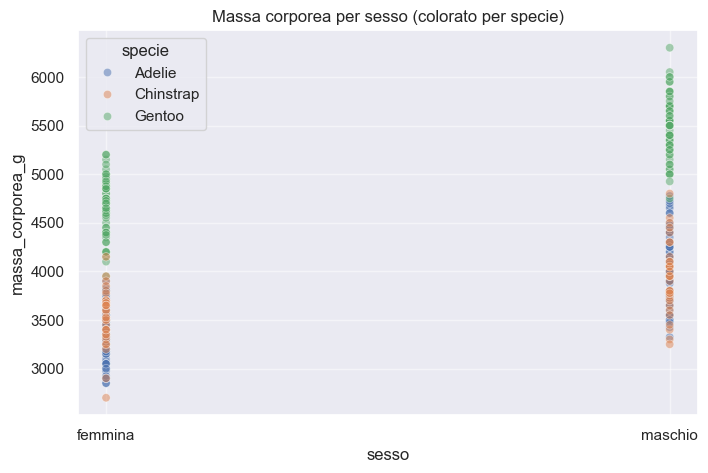

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='sesso', y='massa_corporea_g', hue='specie', alpha=0.5, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['femmina', 'maschio'])
ax.set_title('Massa corporea per sesso (colorato per specie)')
plt.show()

All'interno di ogni specie, i maschi tendono a pesare più delle femmine. La differenza tra specie è molto più marcata di quella tra sessi, con i punti Gentoo (in genere il colore più in alto) chiaramente sopra Adelie e Chinstrap, che invece si sovrappongono parzialmente tra loro.

In [58]:
pd.crosstab(df['sesso'], df['lunghezza_becco_mm_class'], margins=True, normalize='index').round(2)

lunghezza_becco_mm_class,"(32.072, 34.85]","(34.85, 37.6]","(37.6, 40.35]","(40.35, 43.1]","(43.1, 45.85]","(45.85, 48.6]","(48.6, 51.35]","(51.35, 54.1]","(54.1, 56.85]","(56.85, 59.6]"
sesso,,,,,,,,,,
0,0.05,0.21,0.16,0.09,0.22,0.22,0.05,0.00,0.00,0.01
1,0.01,0.04,0.15,0.20,0.06,0.11,0.30,0.09,0.03,0.01
All,0.03,0.13,0.16,0.14,0.14,0.16,0.18,0.05,0.01,0.01


In [49]:
df.groupby('sesso')['lunghezza_becco_mm'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
sesso,,,
0,42.08,4.90,172
1,45.78,5.38,170


Le femmine hanno un becco lungo in media 42.10mm (±4.90mm) su 165 individui, i maschi 45.85mm (±5.37mm) su 168 individui.

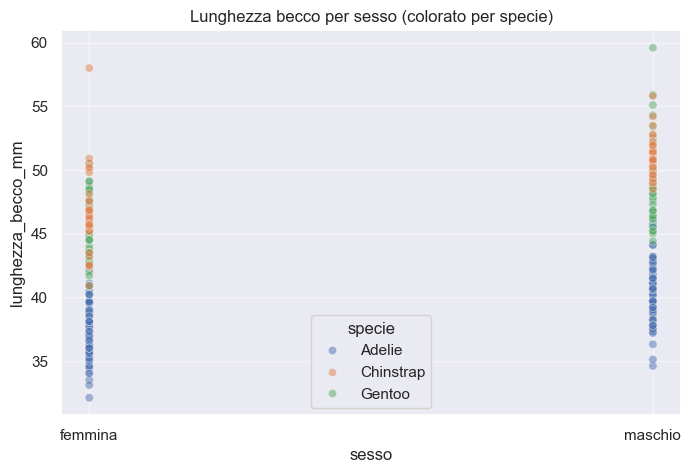

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='sesso', y='lunghezza_becco_mm', hue='specie', alpha=0.5, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['femmina', 'maschio'])
ax.set_title('Lunghezza becco per sesso (colorato per specie)')
plt.show()

I maschi tendono ad avere il becco più lungo delle femmine (coerente con la differenza di circa 3.75mm vista nella tabella precedente); le tre specie occupano fasce diverse di lunghezza becco, con sovrapposizione tra Adelie e Chinstrap mentre Gentoo si distingue maggiormente.

In [53]:
pd.crosstab(df['sesso'], df['lunghezza_pinna_mm_class'], margins=True, normalize='index').round(2)

lunghezza_pinna_mm_class,"(171.941, 177.9]","(177.9, 183.8]","(183.8, 189.7]","(189.7, 195.6]","(195.6, 201.5]","(201.5, 207.4]","(207.4, 213.3]","(213.3, 219.2]","(219.2, 225.1]","(225.1, 231.0]"
sesso,,,,,,,,,,
0,0.02,0.08,0.23,0.24,0.06,0.02,0.19,0.15,0.02,0.00
1,0.00,0.05,0.08,0.22,0.19,0.06,0.06,0.10,0.15,0.09
All,0.01,0.06,0.15,0.23,0.13,0.04,0.12,0.12,0.08,0.04


In [54]:
df.groupby('sesso')['lunghezza_pinna_mm'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
sesso,,,
0,197.59,12.67,172
1,204.28,14.62,170


Femmine in media 197.36mm (±12.50mm) su 165 individui, maschi 204.51mm (±14.55mm) su 168 individui. Anche qui i maschi hanno un valore medio più alto delle femmine, di circa 7.15mm.

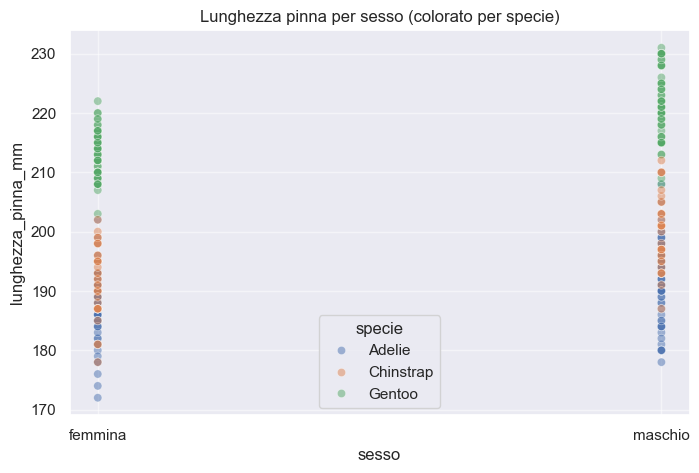

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='sesso', y='lunghezza_pinna_mm', hue='specie', alpha=0.5, ax=ax)
ax.set_xticks([0, 1]); ax.set_xticklabels(['femmina', 'maschio'])
ax.set_title('Lunghezza pinna per sesso (colorato per specie)')
plt.show()

I maschi tendono ad avere la lunghezza della pinna più lunga delle femmine; anche in questo caso tra le specie ci sono sovrapposizioni tra Adelie e Chinstrap mentre Gentoo si distingue maggiormente.

### Indice eta quadro (η²): quanta varianza della massa corporea è spiegata da sesso/specie?

L'indice eta quadro misura quanta parte della varianza totale di una variabile quantitativa è "spiegata" dall'appartenenza ai gruppi di una variabile categorica (rapporto di correlazione).

In [56]:
def eta_quadro(variabile, medie_cond, var_cond, freq_rel):
    mu = variabile.mean()
    sigma2 = variabile.var()
    var_tra_gruppi = (freq_rel * (medie_cond - mu) ** 2).sum()
    var_dentro_gruppi = (freq_rel * var_cond).sum()
    var_totale = var_tra_gruppi + var_dentro_gruppi
    eta2 = var_tra_gruppi / var_totale
    return pd.DataFrame({
        'var_tra_gruppi': [var_tra_gruppi],
        'var_dentro_gruppi': [var_dentro_gruppi],
        'var_totale_ricostruita': [var_totale],
        'varianza_osservata': [sigma2],
        'eta_quadro': [eta2]
    }).round(3)

In [57]:
tab_sesso = df.groupby('sesso')['massa_corporea_g'].agg(['mean', 'var', 'count'])
tab_sesso['f_i'] = tab_sesso['count'] / tab_sesso['count'].sum()

eta2_sesso = eta_quadro(df['massa_corporea_g'], tab_sesso['mean'], tab_sesso['var'], tab_sesso['f_i'])
print('Eta quadro: massa corporea spiegata dal sesso')
eta2_sesso

Eta quadro: massa corporea spiegata dal sesso


,var_tra_gruppi,var_dentro_gruppi,var_totale_ricostruita,varianza_osservata,eta_quadro
0,112392.502,531971.937,644364.44,643131.077,0.174


In [58]:
tab_specie = df.groupby('specie', observed=True)['massa_corporea_g'].agg(['mean', 'var', 'count'])
tab_specie['f_i'] = tab_specie['count'] / tab_specie['count'].sum()

eta2_specie = eta_quadro(df['massa_corporea_g'], tab_specie['mean'], tab_specie['var'], tab_specie['f_i'])
print('Eta quadro: massa corporea spiegata dalla specie')
eta2_specie

Eta quadro: massa corporea spiegata dalla specie


,var_tra_gruppi,var_dentro_gruppi,var_totale_ricostruita,varianza_osservata,eta_quadro
0,429427.527,213612.903,643040.43,643131.077,0.668


La **specie** spiega una quota di varianza della massa corporea molto maggiore rispetto al **sesso** (eta² di 0,18 contro 0,67): appartenere a una specie diversa incide sul peso molto più del sesso all'interno della stessa specie.

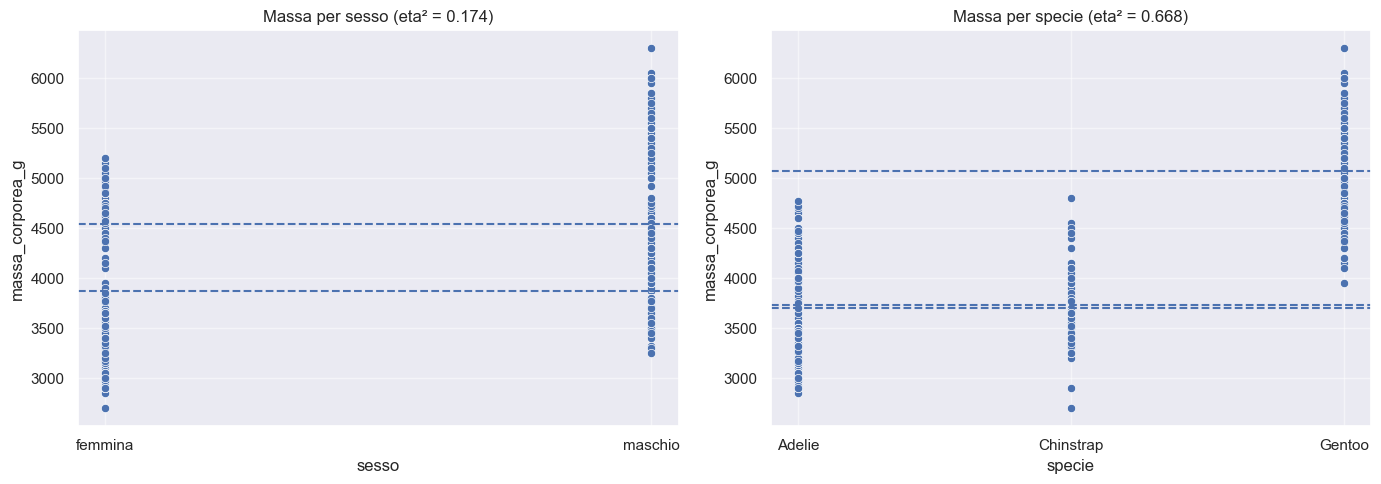

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='sesso', y='massa_corporea_g', ax=ax1)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(['femmina', 'maschio'])
for sesso, m in tab_sesso['mean'].items():
    ax1.axhline(m, linestyle='--')
ax1.set_title(f"Massa per sesso (eta² = {eta2_sesso['eta_quadro'][0]})")

sns.scatterplot(data=df, x='specie', y='massa_corporea_g', ax=ax2)
for specie, m in tab_specie['mean'].items():
    ax2.axhline(m, linestyle='--')
ax2.set_title(f"Massa per specie (eta² = {eta2_specie['eta_quadro'][0]})")

plt.tight_layout()
plt.show()

# 6. Regressione lineare: massa corporea -> lunghezza pinna

Avendo osservato una forte correlazione lineare positiva tra **massa corporea** e **lunghezza della pinna**, si stima un modello di regressione lineare semplice con il metodo dei minimi quadrati ordinari (OLS).

In [54]:
x = df['massa_corporea_g']
y = df['lunghezza_pinna_mm']
X = sm.add_constant(x)

modello = sm.OLS(y, X).fit()
modello.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     lunghezza_pinna_mm   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          4.37e-107
Time:                        13:22:46   Log-Likelihood:                -1145.5
No. Observations:                 342   AIC:                             2295.
Df Residuals:                     340   BIC:                             2303.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              136.7296      1.997     68.473      0.000     132.802     140.657
massa_corporea_g     0.0153      0.000     32.722      0.000       0.014       0.016
==============================================================================
Omnibus:                       11.021   Durbin-Watson:                   1.680
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               11.630
Skew:                          -0.447   Prob(JB):                      0.00298
Kurtosis:                       2.872   Cond. No.                     2.28e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.28e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [55]:
intercetta, coeff = modello.params
print(f"lunghezza_pinna_mm stimata = {intercetta:.4f} + {coeff:.4f} * massa_corporea_g")
print(f"R-quadro = {modello.rsquared:.3f}")

lunghezza_pinna_mm stimata = 136.7296 + 0.0153 * massa_corporea_g
R-quadro = 0.759


**Interpretazione del coefficiente**: a parità di altre condizioni, un aumento di 1 grammo di massa corporea è associato a un aumento medio della lunghezza della pinna di circa il valore del coefficiente (in mm). L'R-quadro indica la quota di varianza della lunghezza della pinna.

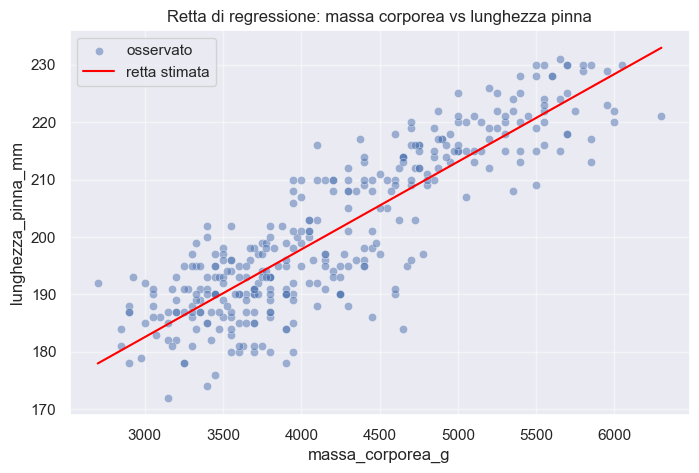

In [56]:
df['lunghezza_pinna_stimata'] = modello.predict(X)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='massa_corporea_g', y='lunghezza_pinna_mm', alpha=0.5, ax=ax, label='osservato')
sns.lineplot(data=df.sort_values('massa_corporea_g'), x='massa_corporea_g', y='lunghezza_pinna_stimata',
             color='red', ax=ax, label='retta stimata')
ax.set_title('Retta di regressione: massa corporea vs lunghezza pinna')
ax.legend()
plt.show()

La retta è positiva e indica una forte correlazione positiva: all'aumentare della massa corporea del pinguino, la lunghezza della sua pinna tende ad aumentare proporzionalmente.
I valori osservati non giaciono perfettamente sulla retta ma formano una nuvola intorno a essa, che passa perfettamente al centro.

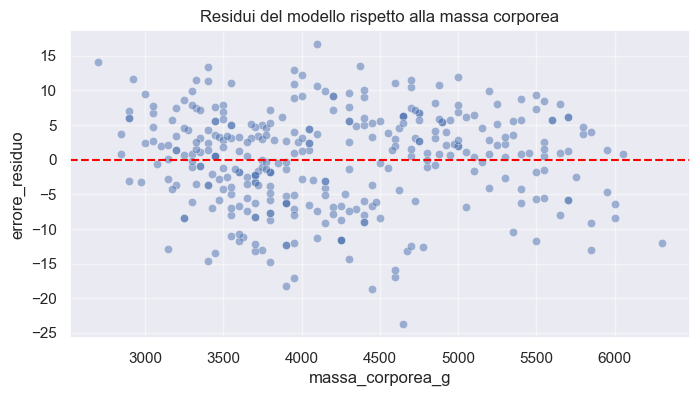

In [57]:
df['errore_residuo'] = df['lunghezza_pinna_mm'] - df['lunghezza_pinna_stimata']

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(data=df, x='massa_corporea_g', y='errore_residuo', alpha=0.5, ax=ax)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residui del modello rispetto alla massa corporea')
plt.show()

I residui si distribuiscono in modo abbastanza casuale attorno allo zero, senza un pattern evidente: è un buon segnale per l'adeguatezza del modello lineare semplice. Si potrebbe comunque migliorare l'adattamento includendo la specie come ulteriore predittore (regressione multipla), dato che le tre specie occupano fasce di massa/pinna diverse.

# 7. Conclusioni

- Il dataset, dopo la pulizia, conta **342 osservazioni complete** su 3 specie (Adelie, Chinstrap, Gentoo) e 3 isole dell'arcipelago Palmer.
- **Specie** e **isola** non sono indipendenti (test chi-quadro altamente significativo, V di Cramer elevato): alcune specie vivono solo su alcune isole.
- La **massa corporea** è fortemente correlata con la **lunghezza della pinna** (correlazione positiva, confermata dal modello di regressione lineare).
- La **lunghezza** e l'**altezza del becco** mostrano una relazione che cambia segno se si controlla per la specie (effetto di variabile confondente e paradosso di Simpson).
- L'indice eta quadro mostra che la **specie** spiega una quota di varianza della massa corporea molto più alta del **sesso**.
- Il modello di regressione lineare semplice massa→pinna ha un buon potere esplicativo (R² nel summary OLS), con residui senza pattern evidenti.